# Лабораторна робота №3 — Візуалізація даних\n\n**Предмет:** ЗПАД  \n**Датасет:** Heart Disease (UCI Machine Learning Repository)  \n**Мета:** Побудувати 7 графіків для візуалізації даних

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Завантаження та Data Cleaning

In [2]:
# Завантаження датасету Heart Disease
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)
print(f"Shape: {df.shape}")
print(f"\nТипи даних:\n{df.dtypes}")
df.head()

Shape: (303, 14)

Типи даних:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
# Перевірка пропущених значень
print("Пропущені значення:")
print(df.isnull().sum())
print(f"\nЗагальна кількість пропусків: {df.isnull().sum().sum()}")

Пропущені значення:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Загальна кількість пропусків: 6


In [ ]:
# Обробка missing values
# Числові — заповнюємо медіаною, категоріальні — модою
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# Бінаризація target: 0 = немає хвороби, 1 = є хвороба
df['num'] = (df['num'] > 0).astype(int)

print(f"Пропусків після очищення: {df.isnull().sum().sum()}")
print(f"\nОписова статистика:")
df.describe()

## 2. Графік 1 — Scatter Plot: Age vs Cholesterol\n\nЗалежність рівня холестерину від віку пацієнта, з кольоровим кодуванням за наявністю серцевої хвороби.

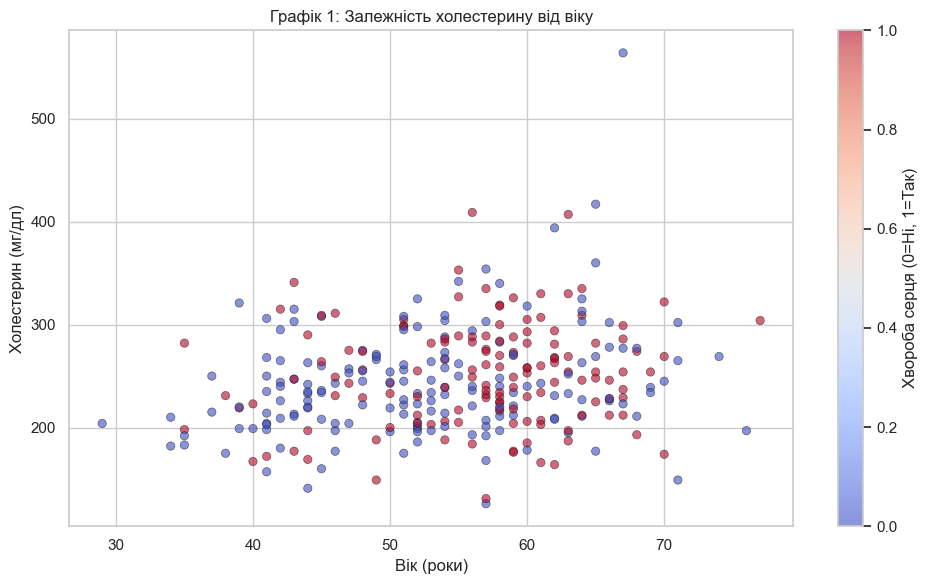

In [5]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['age'], df['chol'], c=df['num'], cmap='coolwarm', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Хвороба серця (0=Ні, 1=Так)')
plt.xlabel('Вік (роки)')
plt.ylabel('Холестерин (мг/дл)')
plt.title('Графік 1: Залежність холестерину від віку')
plt.tight_layout()
plt.show()

## 3. Графік 2 — Line Plot: Середній максимальний пульс по віку\n\nЛінійний графік, що показує як середній максимальний пульс (thalach) змінюється з віком.

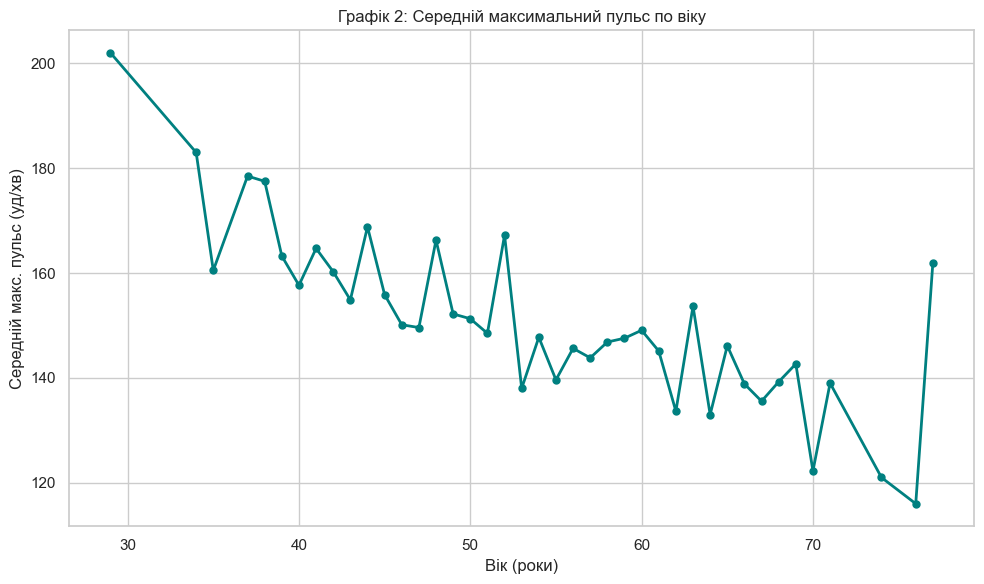

In [6]:
avg_hr = df.groupby('age')['thalach'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(avg_hr['age'], avg_hr['thalach'], marker='o', color='teal', linewidth=2, markersize=5)
plt.xlabel('Вік (роки)')
plt.ylabel('Середній макс. пульс (уд/хв)')
plt.title('Графік 2: Середній максимальний пульс по віку')
plt.tight_layout()
plt.show()

## 4. Графік 3 — Гістограма віку з 5 діапазонами\n\nРозподіл пацієнтів за 5 віковими групами.

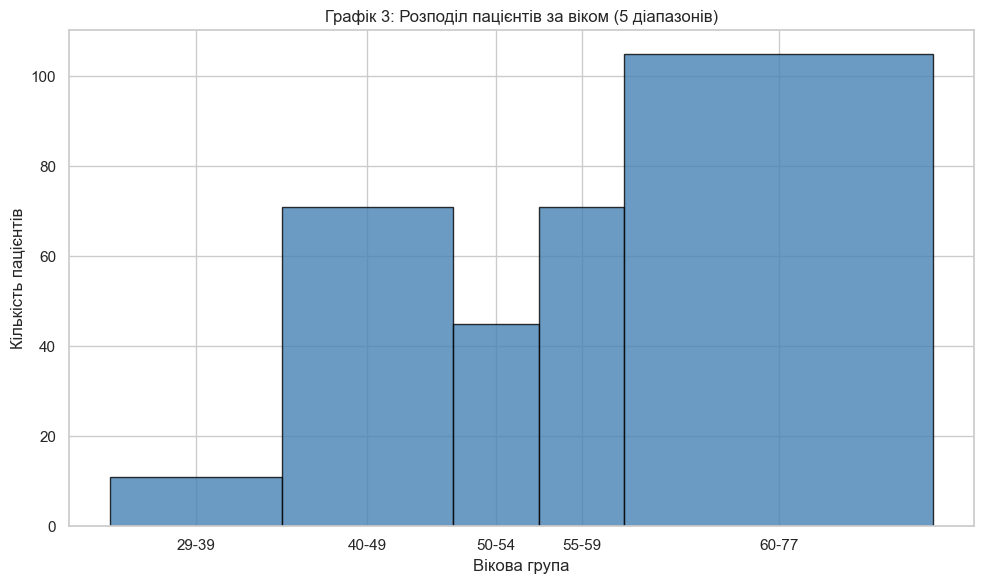

In [7]:
bins = [29, 39, 49, 54, 59, 77]
labels = ['29-39', '40-49', '50-54', '55-59', '60-77']

plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=bins, edgecolor='black', color='steelblue', alpha=0.8)
plt.xlabel('Вікова група')
plt.ylabel('Кількість пацієнтів')
plt.title('Графік 3: Розподіл пацієнтів за віком (5 діапазонів)')
plt.xticks([(bins[i] + bins[i+1]) / 2 for i in range(len(labels))], labels)
plt.tight_layout()
plt.show()

## 5. Графік 4 — Heatmap кореляційної матриці\n\nВізуалізація кореляцій між числовими атрибутами для виявлення залежностей.

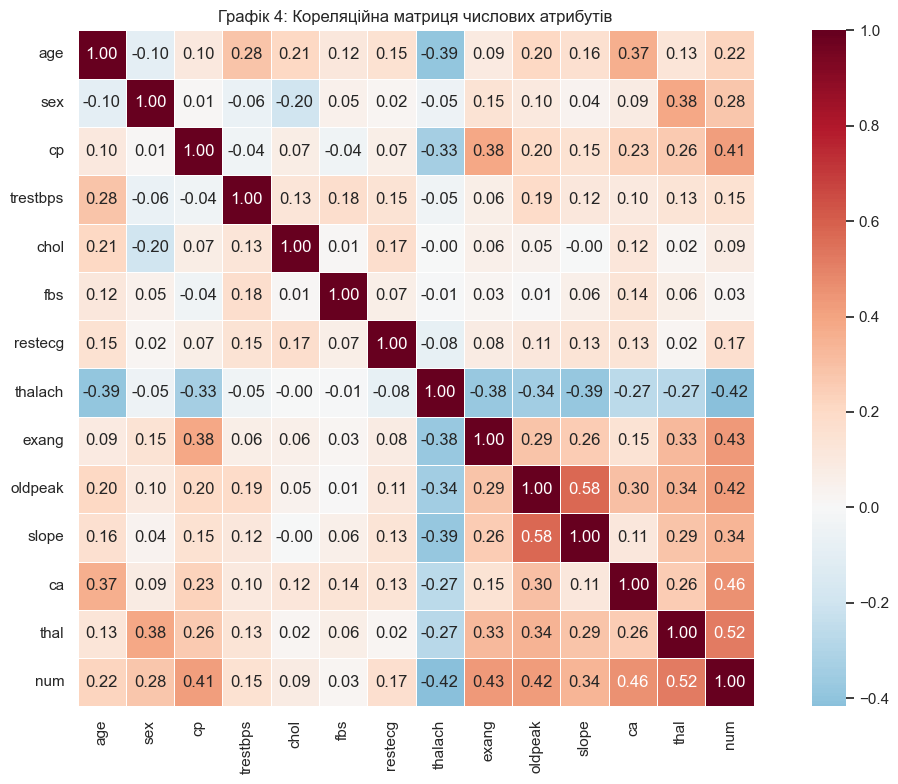

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Графік 4: Кореляційна матриця числових атрибутів')
plt.tight_layout()
plt.show()

## 6. Графік 5 — Box Plot: Холестерин по типу болю в грудях\n\nРозподіл холестерину залежно від типу болю в грудях (cp), з розбивкою по наявності хвороби.

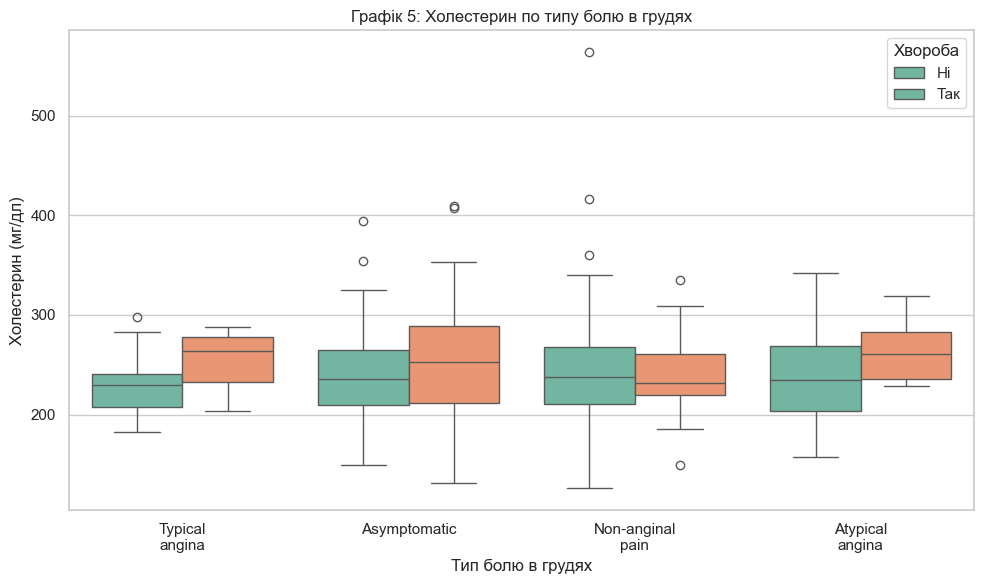

In [9]:
cp_labels = {1: 'Typical\nangina', 2: 'Atypical\nangina', 3: 'Non-anginal\npain', 4: 'Asymptomatic'}
df['cp_label'] = df['cp'].map(cp_labels)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cp_label', y='chol', hue='num', palette='Set2')
plt.xlabel('Тип болю в грудях')
plt.ylabel('Холестерин (мг/дл)')
plt.title('Графік 5: Холестерин по типу болю в грудях')
plt.legend(title='Хвороба', labels=['Ні', 'Так'])
plt.tight_layout()
plt.show()

## 7. Графік 6 — Pair Plot\n\nМатриця діаграм розсіювання для ключових числових атрибутів з кольоровим кодуванням по наявності хвороби серця.

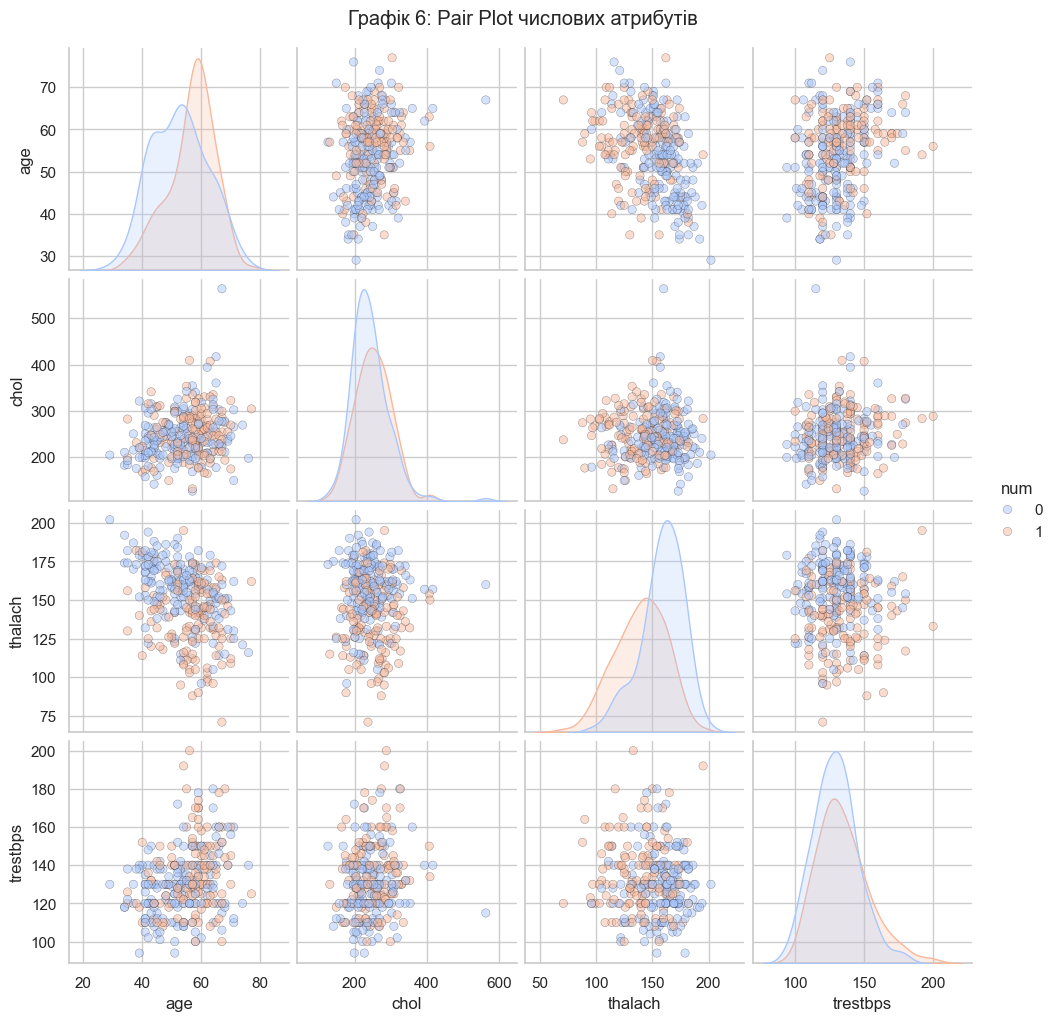

In [10]:
pair_cols = ['age', 'chol', 'thalach', 'trestbps', 'num']
g = sns.pairplot(df[pair_cols], hue='num', palette='coolwarm', diag_kind='kde',
                 plot_kws={'alpha': 0.5, 'edgecolor': 'k', 'linewidth': 0.3})
g.figure.suptitle('Графік 6: Pair Plot числових атрибутів', y=1.02)
plt.show()

## 8. Графік 7 — Violin Plot: Макс. пульс по діагнозу та статі\n\nРозподіл максимального пульсу (thalach) залежно від наявності хвороби серця та статі пацієнта.

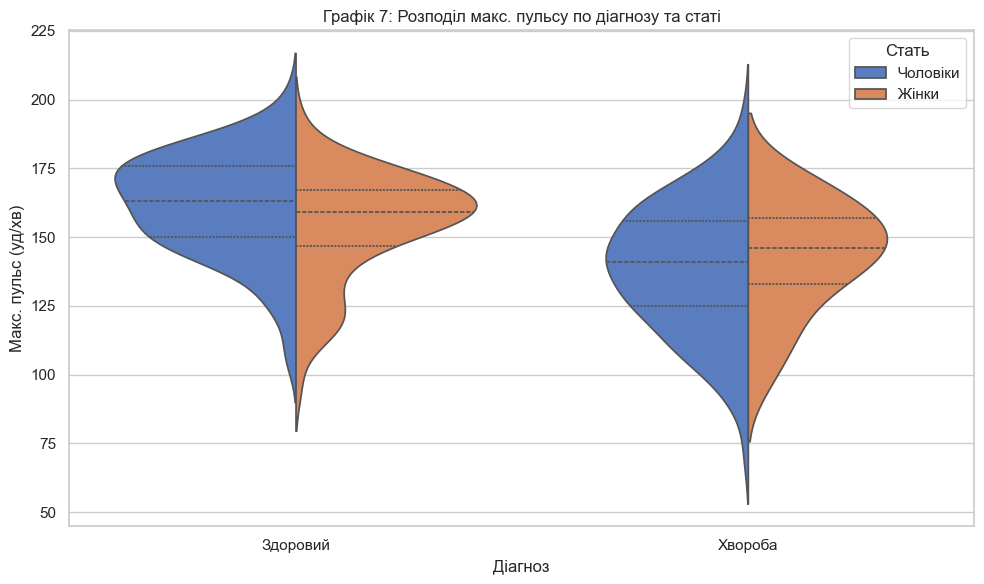

In [11]:
df['sex_label'] = df['sex'].map({0: 'Жінки', 1: 'Чоловіки'})
df['target_label'] = df['num'].map({0: 'Здоровий', 1: 'Хвороба'})

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='target_label', y='thalach', hue='sex_label',
               split=True, palette='muted', inner='quart')
plt.xlabel('Діагноз')
plt.ylabel('Макс. пульс (уд/хв)')
plt.title('Графік 7: Розподіл макс. пульсу по діагнозу та статі')
plt.legend(title='Стать')
plt.tight_layout()
plt.show()